** Name: Ajay Sen

   Roll No: 002211001110

   section:  IT A2

   ML ASSIGNMENT - 4

   Git hub link: https://github.com/Ajay-sen/ML-LAB
**

**<<<<-------- K-means Algo for Iris Dataset -------->>>>**

In [48]:

import numpy as np
import pandas as pd
from collections import Counter
from scipy.optimize import linear_sum_assignment

from sklearn import datasets
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import (
    rand_score,
    adjusted_rand_score,
    mutual_info_score,
    adjusted_mutual_info_score,
    normalized_mutual_info_score,
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
)


In [49]:
# utility functions

def encode_labels(y):
    """Ensure labels are numeric 0,1,2,..."""
    le = LabelEncoder()
    return le.fit_transform(y)

def best_map_accuracy(y_true, y_pred):
    """
    Compute accuracy after optimal mapping between cluster labels and true labels
    using the Hungarian algorithm.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    classes = np.unique(y_true)
    clusters = np.unique(y_pred)
    n_classes = classes.size
    n_clusters = clusters.size

    # build contingency matrix with shape (n_clusters, n_classes)
    contingency = np.zeros((n_clusters, n_classes), dtype=np.int64)
    for i, c in enumerate(clusters):
        mask = (y_pred == c)
        true_counts = Counter(y_true[mask])
        for j, cl in enumerate(classes):
            contingency[i, j] = true_counts.get(cl, 0)

    # Hungarian algorithm on negative contingency to maximize matches
    cost = -contingency
    row_ind, col_ind = linear_sum_assignment(cost)
    matched = contingency[row_ind, col_ind].sum()
    accuracy = matched / y_true.size
    return accuracy

def compute_ssb(X, labels, centroids):
    """
    Sum of squares between groups (SSB) = sum_k n_k * ||mu_k - mu_global||^2
    centroids should be aligned so centroids[k] corresponds to label k (0..max_label)
    """
    X = np.asarray(X)
    labels = np.asarray(labels)
    mu_global = X.mean(axis=0)
    ssb = 0.0
    for k in range(centroids.shape[0]):
        n_k = np.sum(labels == k)
        diff = centroids[k] - mu_global
        ssb += n_k * np.dot(diff, diff)
    return ssb

def evaluate_clustering(X, y_true, y_pred, model=None):
    """
    Compute requested metrics. If model is a fitted KMeans, SSE uses model.inertia_.
    Returns dictionary of metrics.
    """
    results = {}
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    results['rand_score'] = rand_score(y_true, y_pred)
    results['adjusted_rand_score'] = adjusted_rand_score(y_true, y_pred)
    results['mutual_info_score'] = mutual_info_score(y_true, y_pred)
    results['adjusted_mutual_info_score'] = adjusted_mutual_info_score(y_true, y_pred)
    results['normalized_mutual_info_score'] = normalized_mutual_info_score(y_true, y_pred)

    unique_pred = np.unique(y_pred)
    # silhouette requires more than 1 cluster
    if unique_pred.size > 1 and y_pred.size > unique_pred.size:
        results['silhouette'] = silhouette_score(X, y_pred)
    else:
        results['silhouette'] = np.nan

    if unique_pred.size > 1:
        try:
            results['calinski_harabasz'] = calinski_harabasz_score(X, y_pred)
        except Exception:
            results['calinski_harabasz'] = np.nan
        try:
            results['davies_bouldin'] = davies_bouldin_score(X, y_pred)
        except Exception:
            results['davies_bouldin'] = np.nan
    else:
        results['calinski_harabasz'] = np.nan
        results['davies_bouldin'] = np.nan

    # SSE (cohesion)
    if model is not None and hasattr(model, "inertia_"):
        results['SSE'] = float(model.inertia_)
    else:
        # compute SSE manually
        centroids = []
        unique_labels = np.unique(y_pred)
        max_label = int(unique_labels.max())
        for k in range(max_label + 1):
            if k in unique_labels:
                pts = X[y_pred == k]
                centroids.append(pts.mean(axis=0) if pts.size else np.zeros(X.shape[1]))
            else:
                centroids.append(np.zeros(X.shape[1]))
        centroids = np.array(centroids)
        sse = 0.0
        for k in range(centroids.shape[0]):
            pts = X[y_pred == k]
            if pts.size:
                diffs = pts - centroids[k]
                sse += np.sum(np.sum(diffs * diffs, axis=1))
        results['SSE'] = float(sse)

    # SSB (separation)
    unique_pred = np.unique(y_pred)
    max_label = int(unique_pred.max())
    centroids_aligned = []
    for k in range(max_label + 1):
        if k in unique_pred:
            pts = X[y_pred == k]
            centroids_aligned.append(pts.mean(axis=0) if pts.size else np.zeros(X.shape[1]))
        else:
            centroids_aligned.append(np.zeros(X.shape[1]))
    centroids_aligned = np.array(centroids_aligned)
    results['SSB'] = float(compute_ssb(X, y_pred, centroids_aligned))

    # accuracy via Hungarian best mapping
    results['accuracy'] = best_map_accuracy(y_true, y_pred)

    return results


In [50]:
# load Iris dataset and preprocess (standardize)
iris = datasets.load_iris()
X = iris.data.copy()
y = iris.target.copy()  # already numeric, but we'll encode to be safe
y = encode_labels(y)

scaler = StandardScaler()
Xs = scaler.fit_transform(X)

n_clusters = len(np.unique(y))

print(f"Iris loaded: X shape = {Xs.shape}, unique labels = {np.unique(y)}, n_clusters = {n_clusters}")


Iris loaded: X shape = (150, 4), unique labels = [0 1 2], n_clusters = 3


In [51]:
# function to run KMeans (random init) on the Iris dataset

def run_kmeans_random(X, y, n_clusters, random_state=42, n_init=20):
    """
    Fit KMeans with init='random', compute predictions and evaluate.
    Returns (fitted_model, y_pred, metrics_dict)
    """
    km = KMeans(n_clusters=n_clusters, init='random', n_init=n_init, random_state=random_state)
    km.fit(X)
    y_pred = km.labels_
    metrics = evaluate_clustering(X, y, y_pred, model=km)
    metrics['accuracy_percent'] = metrics['accuracy'] * 100.0
    return km, y_pred, metrics


In [52]:
# execute KMeans for Iris, show brief output and save CSV

km_model, y_pred, metrics = run_kmeans_random(Xs, y, n_clusters)
metrics['dataset'] = 'Iris'
metrics['algorithm'] = 'KMeans (init=random)'
metrics['n_clusters'] = n_clusters

# Convert to DataFrame and save
df_results = pd.DataFrame([metrics])
cols_order = [
    'dataset', 'algorithm', 'n_clusters',
    'accuracy_percent', 'rand_score', 'adjusted_rand_score',
    'mutual_info_score', 'adjusted_mutual_info_score', 'normalized_mutual_info_score',
    'silhouette', 'calinski_harabasz', 'davies_bouldin',
    'SSE', 'SSB'
]
df_results = df_results[cols_order]
df_results.to_csv('iris_kmeans_random_results.csv', index=False)

print(f"Completed KMeans (random) for Iris — accuracy: {metrics['accuracy_percent']:.2f}%")
print("Saved 'iris_kmeans_random_results.csv' in the Colab working directory.")


Completed KMeans (random) for Iris — accuracy: 83.33%
Saved 'iris_kmeans_random_results.csv' in the Colab working directory.


In [53]:
# # display results and provide a quick preview / download

# import os
# from IPython.display import display

# df = pd.read_csv('iris_kmeans_random_results.csv')
# pd.set_option('display.precision', 4)
# print("K-means (random init) results for Iris:")
# display(df)

import pandas as pd
from IPython.display import display

df = pd.read_csv('iris_kmeans_random_results.csv')
pd.set_option('display.precision', 4)
print("K-means (random init) results for Iris:")

# Transpose for vertical display
display(df.T)


K-means (random init) results for Iris:


,0
dataset,Iris
algorithm,KMeans (init=random)
n_clusters,3
accuracy_percent,83.3333
rand_score,0.8322
adjusted_rand_score,0.6201
mutual_info_score,0.7241
adjusted_mutual_info_score,0.6552
normalized_mutual_info_score,0.6595
silhouette,0.4599


**<<<<--------K-means for Wine Dataset-------->>>>**

In [54]:
# load and preprocess the Wine dataset
from sklearn import datasets

wine = datasets.load_wine()
X_wine = wine.data.copy()
y_wine = wine.target.copy()
y_wine = encode_labels(y_wine)

scaler = StandardScaler()
X_wine_scaled = scaler.fit_transform(X_wine)

n_clusters_wine = len(np.unique(y_wine))

print(f"Wine loaded: X shape = {X_wine_scaled.shape}, unique labels = {np.unique(y_wine)}, n_clusters = {n_clusters_wine}")


Wine loaded: X shape = (178, 13), unique labels = [0 1 2], n_clusters = 3


In [55]:
# execute KMeans (random init) and save results

km_wine, y_pred_wine, metrics_wine = run_kmeans_random(X_wine_scaled, y_wine, n_clusters_wine)
metrics_wine['dataset'] = 'Wine'
metrics_wine['algorithm'] = 'KMeans (init=random)'
metrics_wine['n_clusters'] = n_clusters_wine

df_wine_results = pd.DataFrame([metrics_wine])
cols_order = [
    'dataset', 'algorithm', 'n_clusters',
    'accuracy_percent', 'rand_score', 'adjusted_rand_score',
    'mutual_info_score', 'adjusted_mutual_info_score', 'normalized_mutual_info_score',
    'silhouette', 'calinski_harabasz', 'davies_bouldin',
    'SSE', 'SSB'
]
df_wine_results = df_wine_results[cols_order]
df_wine_results.to_csv('wine_kmeans_random_results.csv', index=False)

print(f"Completed KMeans (random) for Wine — accuracy: {metrics_wine['accuracy_percent']:.2f}%")
print("Saved 'wine_kmeans_random_results.csv' in the Colab working directory.")


Completed KMeans (random) for Wine — accuracy: 96.63%
Saved 'wine_kmeans_random_results.csv' in the Colab working directory.


In [56]:
# # display results and download

# import os
# from IPython.display import display

# df_wine = pd.read_csv('wine_kmeans_random_results.csv')
# pd.set_option('display.precision', 4)
# print("K-means (random init) results for Wine:")
# display(df_wine)

import pandas as pd
from IPython.display import display, FileLink

# Load data
df_wine = pd.read_csv('wine_kmeans_random_results.csv')
pd.set_option('display.precision', 4)

print("K-means (random init) results for Wine:")

# Display vertically
display(df_wine.T)

# Save (optional, overwrite or new)
output_file = "wine_kmeans_random_results_vertical.csv"
df_wine.to_csv(output_file, index=False)

# Provide download link
display(FileLink(output_file))


K-means (random init) results for Wine:


,0
dataset,Wine
algorithm,KMeans (init=random)
n_clusters,3
accuracy_percent,96.6292
rand_score,0.9543
adjusted_rand_score,0.8975
mutual_info_score,0.9545
adjusted_mutual_info_score,0.8746
normalized_mutual_info_score,0.8759
silhouette,0.2849


/content/wine_kmeans_random_results_vertical.csv

**<<<<--------K-medoids (PAM)  --> Iris Dataset--------->>>>**

In [57]:
# manual K-Medoids (PAM) implementation (no sklearn-extra needed)
import numpy as np
from sklearn.metrics import pairwise_distances

def kmedoids_manual(X, n_clusters, max_iter=300, random_state=42):
    """
    Simple implementation of K-Medoids (PAM)
    """
    np.random.seed(random_state)
    n_samples = X.shape[0]
    # randomly choose initial medoids
    medoid_indices = np.random.choice(n_samples, n_clusters, replace=False)
    medoids = X[medoid_indices]

    for _ in range(max_iter):
        # assign each point to the closest medoid
        distances = pairwise_distances(X, medoids)
        labels = np.argmin(distances, axis=1)

        # update medoids for each cluster
        new_medoids = np.copy(medoids)
        for i in range(n_clusters):
            cluster_points = X[labels == i]
            if len(cluster_points) == 0:
                continue
            intra_dists = pairwise_distances(cluster_points)
            total_dist = np.sum(intra_dists, axis=1)
            best_index = np.argmin(total_dist)
            new_medoids[i] = cluster_points[best_index]

        # stop if medoids didn’t change
        if np.allclose(new_medoids, medoids):
            break
        medoids = new_medoids

    return medoids, labels


In [58]:
# runner for manual K-Medoids (PAM)
def run_kmedoids_pam_manual(X, y, n_clusters, random_state=42):
    medoids, y_pred = kmedoids_manual(X, n_clusters, random_state=random_state)
    metrics = evaluate_clustering(X, y, y_pred, model=None)

    # compute SSE (sum of squared distances to medoids)
    sse = 0.0
    for k, med in enumerate(medoids):
        pts = X[y_pred == k]
        if pts.size:
            diffs = pts - med
            sse += np.sum(np.sum(diffs * diffs, axis=1))
    metrics['SSE'] = float(sse)
    metrics['accuracy_percent'] = metrics['accuracy'] * 100.0
    return medoids, y_pred, metrics


In [59]:
# load Iris dataset and preprocess (standardize)
iris = datasets.load_iris()
X = iris.data.copy()
y = iris.target.copy()  # already numeric, but we'll encode to be safe
y = encode_labels(y)

scaler = StandardScaler()
Xs = scaler.fit_transform(X)

n_clusters = len(np.unique(y))

print(f"Iris loaded: X shape = {Xs.shape}, unique labels = {np.unique(y)}, n_clusters = {n_clusters}")


Iris loaded: X shape = (150, 4), unique labels = [0 1 2], n_clusters = 3


In [60]:
# run manual K-Medoids (PAM) on the Iris dataset
# (uses Xs, y, and n_clusters already created earlier for Iris)

medoids_iris, y_pred_iris, metrics_iris = run_kmedoids_pam_manual(Xs, y, n_clusters)
metrics_iris['dataset'] = 'Iris'
metrics_iris['algorithm'] = 'KMedoids (PAM - manual)'
metrics_iris['n_clusters'] = n_clusters

df_iris_kmed = pd.DataFrame([metrics_iris])
cols_order = [
    'dataset', 'algorithm', 'n_clusters',
    'accuracy_percent', 'rand_score', 'adjusted_rand_score',
    'mutual_info_score', 'adjusted_mutual_info_score', 'normalized_mutual_info_score',
    'silhouette', 'calinski_harabasz', 'davies_bouldin',
    'SSE', 'SSB'
]
df_iris_kmed = df_iris_kmed[cols_order]
df_iris_kmed.to_csv('iris_kmedoids_pam_results.csv', index=False)

print(f"Completed K-Medoids (PAM) for Iris — accuracy: {metrics_iris['accuracy_percent']:.2f}%")
print("Saved 'iris_kmedoids_pam_results.csv' in the Colab working directory.")


Completed K-Medoids (PAM) for Iris — accuracy: 86.00%
Saved 'iris_kmedoids_pam_results.csv' in the Colab working directory.


In [61]:
# # display the K-Medoids (PAM) results for Iris
# import os
# from IPython.display import display

# df_iris_kmed = pd.read_csv('iris_kmedoids_pam_results.csv')
# pd.set_option('display.precision', 4)
# print("K-Medoids (PAM - manual) results for Iris:")
# display(df_iris_kmed)

import pandas as pd
from IPython.display import display, FileLink

# Load data
df_iris_kmed = pd.read_csv('iris_kmedoids_pam_results.csv')
pd.set_option('display.precision', 4)

print("K-Medoids (PAM - manual) results for Iris:")

# Display vertically
display(df_iris_kmed.T)

# Save and provide download link
output_file = "iris_kmedoids_pam_results_vertical.csv"
df_iris_kmed.to_csv(output_file, index=False)
display(FileLink(output_file))


K-Medoids (PAM - manual) results for Iris:


,0
dataset,Iris
algorithm,KMedoids (PAM - manual)
n_clusters,3
accuracy_percent,86.0
rand_score,0.8515
adjusted_rand_score,0.6676
mutual_info_score,0.7692
adjusted_mutual_info_score,0.7038
normalized_mutual_info_score,0.7075
silhouette,0.4605


/content/iris_kmedoids_pam_results_vertical.csv

**<<<<--------K-medoids (PAM) --> Wine Dataset-------->>>>**

In [62]:
# execute manual K-Medoids (PAM) for Wine and save results
# Assumes: X_wine_scaled, y_wine, n_clusters_wine, and run_kmedoids_pam_manual are available.

medoids_wine, y_pred_wine, metrics_wine = run_kmedoids_pam_manual(X_wine_scaled, y_wine, n_clusters_wine)
metrics_wine['dataset'] = 'Wine'
metrics_wine['algorithm'] = 'KMedoids (PAM - manual)'
metrics_wine['n_clusters'] = n_clusters_wine

df_wine_kmed = pd.DataFrame([metrics_wine])
cols_order = [
    'dataset', 'algorithm', 'n_clusters',
    'accuracy_percent', 'rand_score', 'adjusted_rand_score',
    'mutual_info_score', 'adjusted_mutual_info_score', 'normalized_mutual_info_score',
    'silhouette', 'calinski_harabasz', 'davies_bouldin',
    'SSE', 'SSB'
]
df_wine_kmed = df_wine_kmed[cols_order]
df_wine_kmed.to_csv('wine_kmedoids_pam_results.csv', index=False)

print(f"Completed K-Medoids (PAM - manual) for Wine — accuracy: {metrics_wine['accuracy_percent']:.2f}%")
print("Saved 'wine_kmedoids_pam_results.csv' in the Colab working directory.")


Completed K-Medoids (PAM - manual) for Wine — accuracy: 66.29%
Saved 'wine_kmedoids_pam_results.csv' in the Colab working directory.


In [63]:
# print medoids (in original scaled space) and cluster sizes for Wine
import numpy as np
unique, counts = np.unique(y_pred_wine, return_counts=True)
cluster_info = dict(zip(unique.tolist(), counts.tolist()))
print("Cluster sizes (label: size):", cluster_info)

# Show medoids (scaled features)
print("\nMedoids (scaled feature vectors):")
for i, med in enumerate(medoids_wine):
    print(f"Medoid {i}: {med}")


Cluster sizes (label: size): {0: 89, 1: 24, 2: 65}

Medoids (scaled feature vectors):
Medoid 0: [ 0.59216382 -0.47248348  0.15894572  0.30180329  0.01814502  0.64876424
  0.95450162 -0.82071924  0.47148781  0.01812906  0.36217728  1.2123203
  0.55125733]
Medoid 1: [ 0.29570023  1.47544554 -0.27969519 -0.59905169  0.22878504  0.55262435
  0.60311327 -0.33725087  0.12107098 -0.30197273 -0.60303724  0.54847218
 -0.21302116]
Medoid 2: [-0.05017396  0.99968408 -0.06037473 -0.2987667   0.43942506 -1.45029009
 -1.33454251  0.30737361 -1.14042959  0.09599166 -1.21726466 -1.21708134
 -0.22894363]


In [64]:
# # display the K-Medoids (PAM) results for Wine and provide download link
# import os
# from IPython.display import display

# df_wine_kmed = pd.read_csv('wine_kmedoids_pam_results.csv')
# pd.set_option('display.precision', 4)
# print("K-Medoids (PAM - manual) results for Wine:")
# display(df_wine_kmed)


import pandas as pd
from IPython.display import display, FileLink

# Load data
df_wine_kmed = pd.read_csv('wine_kmedoids_pam_results.csv')
pd.set_option('display.precision', 4)

print("K-Medoids (PAM - manual) results for Wine:")

# Display vertically
display(df_wine_kmed.T)

# Save and create download link
output_file = "wine_kmedoids_pam_results_vertical.csv"
df_wine_kmed.to_csv(output_file, index=False)
display(FileLink(output_file))



K-Medoids (PAM - manual) results for Wine:


,0
dataset,Wine
algorithm,KMedoids (PAM - manual)
n_clusters,3
accuracy_percent,66.2921
rand_score,0.6924
adjusted_rand_score,0.3413
mutual_info_score,0.4317
adjusted_mutual_info_score,0.4104
normalized_mutual_info_score,0.417
silhouette,0.1548


/content/wine_kmedoids_pam_results_vertical.csv

**<<<<--------Hierarchical: Dendrogram (Iris Dataset)-------->>>>**

In [65]:
# imports for hierarchical clustering and plotting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering
# other utilities (evaluate_clustering, encode_labels, etc.) assumed present
# In Colab, ensure plots display inline:
%matplotlib inline


In [66]:
# helper functions for hierarchical clustering and dendrogram

def plot_dendrogram_linkage(X, method='ward', metric='euclidean', truncate_mode=None, p=30, figsize=(10, 6), title="Dendrogram (Hierarchical)"):
    """
    Compute linkage and plot dendrogram.
    - truncate_mode: None or 'lastp' or 'level' (see scipy docs). Use lastp with p to show last p merges.
    """
    Z = linkage(X, method=method, metric=metric)
    plt.figure(figsize=figsize)
    dendrogram(Z, truncate_mode=truncate_mode, p=p, leaf_rotation=90., leaf_font_size=10., show_contracted=True)
    plt.title(title + f" — method={method}, metric={metric}")
    plt.xlabel("Sample index or (cluster size)")
    plt.ylabel("Distance")
    plt.tight_layout()
    return Z

def hierarchical_cluster_and_evaluate(X, y, n_clusters, linkage_method='ward', affinity='euclidean'):
    """
    Runs AgglomerativeClustering with the requested number of clusters,
    returns the fitted clustering, labels and metrics (using evaluate_clustering).
    Note: sklearn's AgglomerativeClustering uses 'affinity' for pre-1.2 naming; newer versions use 'metric'.
    """
    # Fit AgglomerativeClustering to obtain flat clusters
    # sklearn's AgglomerativeClustering with linkage='ward' requires affinity/metric='euclidean'
    if linkage_method == 'ward':
        ac = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage_method)
    else:
        ac = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage_method, affinity=affinity)
    y_pred = ac.fit_predict(X)
    metrics = evaluate_clustering(X, y, y_pred, model=None)
    # compute SSE manually: sum squared distances to cluster centroid
    unique = np.unique(y_pred)
    sse = 0.0
    centroids = []
    max_label = int(unique.max())
    for k in range(max_label + 1):
        if k in unique:
            pts = X[y_pred == k]
            c = pts.mean(axis=0) if pts.size else np.zeros(X.shape[1])
            centroids.append(c)
            diffs = pts - c
            sse += np.sum(np.sum(diffs * diffs, axis=1)) if pts.size else 0.0
        else:
            centroids.append(np.zeros(X.shape[1]))
    centroids = np.array(centroids)
    metrics['SSE'] = float(sse)
    metrics['SSB'] = float(compute_ssb(X, y_pred, centroids))
    metrics['accuracy_percent'] = metrics['accuracy'] * 100.0
    return ac, y_pred, metrics, centroids


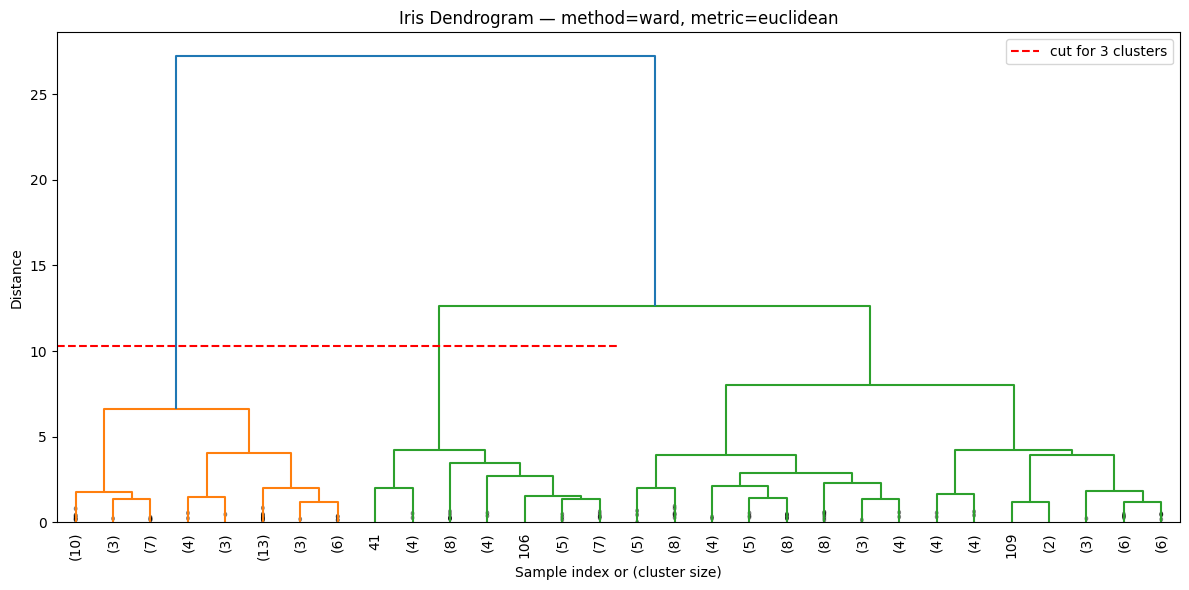

In [67]:
# compute linkage and plot dendrogram for Iris (Xs assumed standardized)
# Tweak method/parameters if you prefer a different linkage (e.g., 'complete', 'average').

Z = plot_dendrogram_linkage(Xs, method='ward', metric='euclidean', truncate_mode='lastp', p=30,
                            figsize=(12,6), title="Iris Dendrogram")

# Optionally plot an horizontal line to indicate cut corresponding to n_clusters (visual aid)
# We can estimate cut threshold by inspecting distances in Z; for convenience, draw a horizontal line:
# find the (n_clusters-1)-th largest merge distance and draw line slightly below it
from scipy.cluster.hierarchy import inconsistent
# get linkage distances
dists = Z[:, 2]
# pick threshold as midpoint between the (n_clusters-1)-th and next largest merge (safe fallback)
if len(dists) >= n_clusters:
    sorted_desc = np.sort(dists)[::-1]
    thresh = (sorted_desc[n_clusters-2] + sorted_desc[n_clusters-1]) / 2.0 if len(sorted_desc) >= n_clusters else sorted_desc[n_clusters-2]
    plt.hlines(thresh, xmin=0, xmax=len(Xs), colors='r', linestyles='dashed', label=f'cut for {n_clusters} clusters')
    plt.legend()
    plt.show()
else:
    plt.show()


In [68]:
# run hierarchical clustering (obtain flat clusters), evaluate, and save metrics

# Choose linkage method to use (common choices: 'ward', 'complete', 'average', 'single')
chosen_linkage = 'ward'   # change if you want to compare methods
ac_model, y_pred_hier, metrics_hier, centroids_hier = hierarchical_cluster_and_evaluate(Xs, y, n_clusters, linkage_method=chosen_linkage)

metrics_hier['dataset'] = 'Iris'
metrics_hier['algorithm'] = f'Hierarchical ({chosen_linkage})'
metrics_hier['n_clusters'] = n_clusters

df_iris_hier = pd.DataFrame([metrics_hier])
cols_order = [
    'dataset', 'algorithm', 'n_clusters',
    'accuracy_percent', 'rand_score', 'adjusted_rand_score',
    'mutual_info_score', 'adjusted_mutual_info_score', 'normalized_mutual_info_score',
    'silhouette', 'calinski_harabasz', 'davies_bouldin',
    'SSE', 'SSB'
]
df_iris_hier = df_iris_hier[cols_order]
df_iris_hier.to_csv('iris_hierarchical_results.csv', index=False)

print(f"Completed Hierarchical ({chosen_linkage}) for Iris — accuracy: {metrics_hier['accuracy_percent']:.2f}%")
print("Saved 'iris_hierarchical_results.csv' in the Colab working directory.")


Completed Hierarchical (ward) for Iris — accuracy: 82.67%
Saved 'iris_hierarchical_results.csv' in the Colab working directory.


In [69]:
# # display results and show cluster sizes; provide download link

# from IPython.display import display

# df_iris_hier = pd.read_csv('iris_hierarchical_results.csv')
# pd.set_option('display.precision', 4)
# print("Hierarchical clustering results for Iris:")
# display(df_iris_hier)

# # cluster sizes
# unique, counts = np.unique(y_pred_hier, return_counts=True)
# print("\nCluster sizes (label: size):", dict(zip(unique.tolist(), counts.tolist())))

# # optional: show centroids (in scaled space)
# print("\nCentroids (scaled features) for each cluster:")
# for i, c in enumerate(centroids_hier):
#     print(f"Cluster {i}: {np.round(c, 4)}")

import pandas as pd
import numpy as np
from IPython.display import display, FileLink

# Load results
df_iris_hier = pd.read_csv('iris_hierarchical_results.csv')
pd.set_option('display.precision', 4)

print("Hierarchical clustering results for Iris:")

# Display vertically
display(df_iris_hier.T)

# Show cluster sizes
unique, counts = np.unique(y_pred_hier, return_counts=True)
print("\nCluster sizes (label: size):", dict(zip(unique.tolist(), counts.tolist())))

# Show centroids (scaled space)
print("\nCentroids (scaled features) for each cluster:")
for i, c in enumerate(centroids_hier):
    print(f"Cluster {i}: {np.round(c, 4)}")

# Save and provide download link
output_file = "iris_hierarchical_results_vertical.csv"
df_iris_hier.to_csv(output_file, index=False)
display(FileLink(output_file))


Hierarchical clustering results for Iris:


,0
dataset,Iris
algorithm,Hierarchical (ward)
n_clusters,3
accuracy_percent,82.6667
rand_score,0.8252
adjusted_rand_score,0.6153
mutual_info_score,0.7228
adjusted_mutual_info_score,0.6713
normalized_mutual_info_score,0.6755
silhouette,0.4467



Cluster sizes (label: size): {0: 71, 1: 49, 2: 30}

Centroids (scaled features) for each cluster:
Cluster 0: [ 0.852  -0.1482  0.858   0.863 ]
Cluster 1: [-1.0021  0.9063 -1.3031 -1.2563]
Cluster 2: [-0.3797 -1.1295  0.0978  0.0097]


/content/iris_hierarchical_results_vertical.csv

**<<<<--------Hierarchical: Dendrogram (Wine Dataset)-------->>>>**

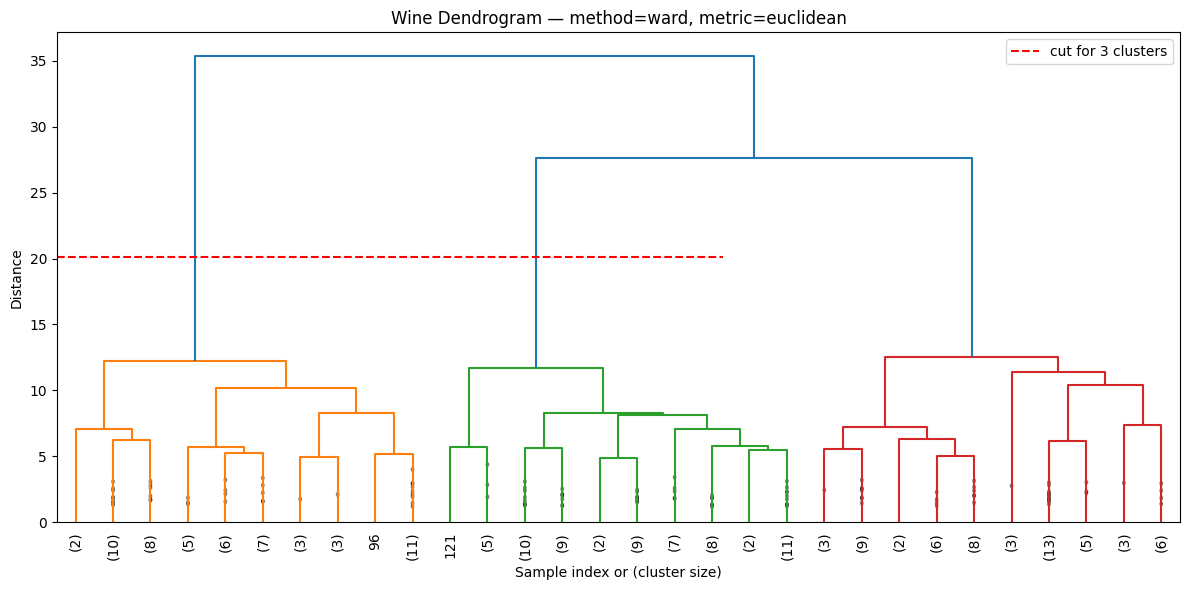

In [70]:
# compute linkage and plot dendrogram for Wine (X_wine_scaled assumed standardized)
# Tweak method/parameters if you prefer a different linkage (e.g., 'complete', 'average').

Z_wine = linkage(X_wine_scaled, method='ward', metric='euclidean')
plt.figure(figsize=(12,6))
dendrogram(Z_wine, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=10., show_contracted=True)
plt.title("Wine Dendrogram — method=ward, metric=euclidean")
plt.xlabel("Sample index or (cluster size)")
plt.ylabel("Distance")

# Draw horizontal cut line for n_clusters_wine (visual aid): choose threshold from linkage distances
dists_w = Z_wine[:, 2]
if len(dists_w) >= n_clusters_wine:
    sorted_desc = np.sort(dists_w)[::-1]
    if len(sorted_desc) >= n_clusters_wine:
        thresh = (sorted_desc[n_clusters_wine-2] + sorted_desc[n_clusters_wine-1]) / 2.0
        plt.hlines(thresh, xmin=0, xmax=len(X_wine_scaled), colors='r', linestyles='dashed', label=f'cut for {n_clusters_wine} clusters')
        plt.legend()
plt.tight_layout()
plt.show()


In [71]:
# run AgglomerativeClustering (Hierarchical) on Wine, evaluate and save metrics
# Choose linkage method to use (change 'ward' if you want to compare methods)
chosen_linkage_wine = 'ward'

# For 'ward' linkage sklearn requires euclidean metric; AgglomerativeClustering signature varies by sklearn version.
if chosen_linkage_wine == 'ward':
    ac_wine = AgglomerativeClustering(n_clusters=n_clusters_wine, linkage=chosen_linkage_wine)
else:
    ac_wine = AgglomerativeClustering(n_clusters=n_clusters_wine, linkage=chosen_linkage_wine, affinity='euclidean')

y_pred_hier_wine = ac_wine.fit_predict(X_wine_scaled)
metrics_hier_wine = evaluate_clustering(X_wine_scaled, y_wine, y_pred_hier_wine, model=None)

# compute SSE and centroids for SSB
unique = np.unique(y_pred_hier_wine)
sse_wine = 0.0
centroids_wine = []
max_label = int(unique.max())
for k in range(max_label + 1):
    if k in unique:
        pts = X_wine_scaled[y_pred_hier_wine == k]
        c = pts.mean(axis=0) if pts.size else np.zeros(X_wine_scaled.shape[1])
        centroids_wine.append(c)
        if pts.size:
            diffs = pts - c
            sse_wine += np.sum(np.sum(diffs * diffs, axis=1))
    else:
        centroids_wine.append(np.zeros(X_wine_scaled.shape[1]))
centroids_wine = np.array(centroids_wine)

metrics_hier_wine['SSE'] = float(sse_wine)
metrics_hier_wine['SSB'] = float(compute_ssb(X_wine_scaled, y_pred_hier_wine, centroids_wine))
metrics_hier_wine['accuracy_percent'] = metrics_hier_wine['accuracy'] * 100.0

metrics_hier_wine['dataset'] = 'Wine'
metrics_hier_wine['algorithm'] = f'Hierarchical ({chosen_linkage_wine})'
metrics_hier_wine['n_clusters'] = n_clusters_wine

df_wine_hier = pd.DataFrame([metrics_hier_wine])
cols_order = [
    'dataset', 'algorithm', 'n_clusters',
    'accuracy_percent', 'rand_score', 'adjusted_rand_score',
    'mutual_info_score', 'adjusted_mutual_info_score', 'normalized_mutual_info_score',
    'silhouette', 'calinski_harabasz', 'davies_bouldin',
    'SSE', 'SSB'
]
df_wine_hier = df_wine_hier[cols_order]
df_wine_hier.to_csv('wine_hierarchical_results.csv', index=False)

print(f"Completed Hierarchical ({chosen_linkage_wine}) for Wine — accuracy: {metrics_hier_wine['accuracy_percent']:.2f}%")
print("Saved 'wine_hierarchical_results.csv' in the Colab working directory.")


Completed Hierarchical (ward) for Wine — accuracy: 92.70%
Saved 'wine_hierarchical_results.csv' in the Colab working directory.


In [72]:
# # display hierarchical results for Wine and show cluster sizes; provide download link

# from IPython.display import display

# df_wine_hier = pd.read_csv('wine_hierarchical_results.csv')
# pd.set_option('display.precision', 4)
# print("Hierarchical clustering results for Wine:")
# display(df_wine_hier)

# # cluster sizes
# unique_w, counts_w = np.unique(y_pred_hier_wine, return_counts=True)
# print("\nCluster sizes (label: size):", dict(zip(unique_w.tolist(), counts_w.tolist())))

# # show centroids (scaled)
# print("\nCentroids (scaled features) for each cluster:")
# for i, c in enumerate(centroids_wine):
#     print(f"Cluster {i}: {np.round(c, 4)}")

import pandas as pd
import numpy as np
from IPython.display import display, FileLink

# Load results
df_wine_hier = pd.read_csv('wine_hierarchical_results.csv')
pd.set_option('display.precision', 4)

print("Hierarchical clustering results for Wine:")

# Display vertically
display(df_wine_hier.T)

# Cluster sizes
unique_w, counts_w = np.unique(y_pred_hier_wine, return_counts=True)
print("\nCluster sizes (label: size):", dict(zip(unique_w.tolist(), counts_w.tolist())))

# Centroids (scaled space)
print("\nCentroids (scaled features) for each cluster:")
for i, c in enumerate(centroids_wine):
    print(f"Cluster {i}: {np.round(c, 4)}")




Hierarchical clustering results for Wine:


,0
dataset,Wine
algorithm,Hierarchical (ward)
n_clusters,3
accuracy_percent,92.6966
rand_score,0.9065
adjusted_rand_score,0.7899
mutual_info_score,0.8584
adjusted_mutual_info_score,0.7842
normalized_mutual_info_score,0.7865
silhouette,0.2774



Cluster sizes (label: size): {0: 58, 1: 56, 2: 64}

Centroids (scaled features) for each cluster:
Cluster 0: [-0.9841 -0.3567 -0.5532  0.2143 -0.5048 -0.0516  0.0591 -0.0524  0.1676
 -0.9355  0.4499  0.3539 -0.7817]
Cluster 1: [ 0.0753  0.7453  0.1694  0.453   0.0081 -0.9627 -1.1861  0.7059 -0.8088
  0.7752 -1.0374 -1.2491 -0.3883]
Cluster 2: [ 0.8259 -0.3289  0.3531 -0.5906  0.4504  0.8891  0.9843 -0.5702  0.5558
  0.1695  0.5     0.7723  1.0482]


**<<<<--------DBSCAN and OPTICS Algo on Iris Dataset-------->>>>**

In [73]:
# imports for DBSCAN and OPTICS (skip if already imported)
from sklearn.cluster import DBSCAN, OPTICS
from sklearn.neighbors import NearestNeighbors
import numpy as np
import pandas as pd

In [74]:
# helper to relabel cluster labels to contiguous integers (keeps noise as its own label if present)
def relabel_contiguous(labels):
    """
    Map arbitrary labels (e.g., -1, 0, 2, 5) to contiguous labels 0..K-1
    Returns (new_labels, mapping_dict)
    """
    uniq = np.unique(labels)
    mapping = {old: new for new, old in enumerate(uniq)}
    new_labels = np.array([mapping[l] for l in labels])
    return new_labels, mapping

def evaluate_density_clustering(X, y_true, raw_labels, algo_name="DBSCAN/OPTICS", eps_or_params=None):
    """
    Relabel labels to contiguous integers, evaluate using evaluate_clustering,
    and include algorithm-specific info in returned metrics.
    """
    # Convert raw_labels to contiguous ints
    y_pred_contig, mapping = relabel_contiguous(raw_labels)
    metrics = evaluate_clustering(X, y_true, y_pred_contig, model=None)
    # SSE: compute sum of squared distances to cluster centroid (ignoring empty clusters if any)
    unique = np.unique(y_pred_contig)
    sse = 0.0
    centroids = []
    max_label = int(unique.max())
    for k in range(max_label + 1):
        if k in unique:
            pts = X[y_pred_contig == k]
            c = pts.mean(axis=0) if pts.size else np.zeros(X.shape[1])
            centroids.append(c)
            if pts.size:
                diffs = pts - c
                sse += np.sum(np.sum(diffs * diffs, axis=1))
        else:
            centroids.append(np.zeros(X.shape[1]))
    centroids = np.array(centroids)
    metrics['SSE'] = float(sse)
    metrics['SSB'] = float(compute_ssb(X, y_pred_contig, centroids))
    metrics['accuracy_percent'] = metrics['accuracy'] * 100.0
    metrics['algorithm'] = algo_name
    metrics['params'] = str(eps_or_params)
    return metrics, y_pred_contig, mapping


In [75]:
# run DBSCAN on Iris
# Typical starting eps for standardized data ~ 0.3..1.0; min_samples default 5.
dbscan_eps = 0.5
dbscan_min_samples = 5

db = DBSCAN(eps=dbscan_eps, min_samples=dbscan_min_samples, metric='euclidean')
y_db_raw = db.fit_predict(Xs)   # raw labels may contain -1 for noise

metrics_db, y_db_pred, map_db = evaluate_density_clustering(Xs, y, y_db_raw, algo_name="DBSCAN", eps_or_params=f"eps={dbscan_eps}, min_samples={dbscan_min_samples}")
metrics_db['dataset'] = 'Iris'
metrics_db['n_clusters_detected'] = len(np.unique(y_db_pred))
metrics_db['n_noise_points'] = int(np.sum(y_db_raw == -1)) if (-1 in np.unique(y_db_raw)) else 0

# Save CSV
df_db = pd.DataFrame([metrics_db])
cols_order = [
    'dataset', 'algorithm', 'params', 'n_clusters_detected', 'n_noise_points', 'accuracy_percent',
    'rand_score', 'adjusted_rand_score',
    'mutual_info_score', 'adjusted_mutual_info_score', 'normalized_mutual_info_score',
    'silhouette', 'calinski_harabasz', 'davies_bouldin',
    'SSE', 'SSB'
]
df_db = df_db[cols_order]
df_db.to_csv('iris_dbscan_results.csv', index=False)

print(f"Completed DBSCAN for Iris — detected clusters: {metrics_db['n_clusters_detected']}, noise points: {metrics_db['n_noise_points']}, accuracy: {metrics_db['accuracy_percent']:.2f}%")
print("Saved 'iris_dbscan_results.csv' in the Colab working directory.")


Completed DBSCAN for Iris — detected clusters: 3, noise points: 34, accuracy: 68.00%
Saved 'iris_dbscan_results.csv' in the Colab working directory.


In [76]:
# run OPTICS on Iris
# OPTICS can be used to extract clusters via reachability; here we use default parameters and extract labels via clustering='xi' or via DBSCAN-style eps
optics_min_samples = 5
optics_cluster_method = 'xi'   # alternatives: 'dbscan' with eps parameter
optics_xi = 0.05

opt = OPTICS(min_samples=optics_min_samples, metric='euclidean')
opt.fit(Xs)
# get labels: if using 'xi' extraction
if optics_cluster_method == 'xi':
    y_opt_raw = opt.labels_
else:
    # for 'dbscan' extraction provide eps
    eps_opt = 0.5
    y_opt_raw = opt.fit_predict(Xs, cluster_method='dbscan', eps=eps_opt)

metrics_opt, y_opt_pred, map_opt = evaluate_density_clustering(Xs, y, y_opt_raw, algo_name="OPTICS", eps_or_params=f"method={optics_cluster_method}, min_samples={optics_min_samples}, xi={optics_xi if optics_cluster_method=='xi' else eps_opt}")
metrics_opt['dataset'] = 'Iris'
metrics_opt['n_clusters_detected'] = len(np.unique(y_opt_pred))
metrics_opt['n_noise_points'] = int(np.sum(y_opt_raw == -1)) if (-1 in np.unique(y_opt_raw)) else 0

df_opt = pd.DataFrame([metrics_opt])
df_opt = df_opt[cols_order]
df_opt.to_csv('iris_optics_results.csv', index=False)

print(f"Completed OPTICS for Iris — detected clusters: {metrics_opt['n_clusters_detected']}, noise points: {metrics_opt['n_noise_points']}, accuracy: {metrics_opt['accuracy_percent']:.2f}%")
print("Saved 'iris_optics_results.csv' in the Colab working directory.")


Completed OPTICS for Iris — detected clusters: 6, noise points: 109, accuracy: 44.67%
Saved 'iris_optics_results.csv' in the Colab working directory.


In [77]:
# # display results and download CSVs; print cluster sizes for DBSCAN & OPTICS

# from IPython.display import display

# # DBSCAN
# df_db = pd.read_csv('iris_dbscan_results.csv')
# print("DBSCAN results for Iris:")
# display(df_db)

# unique_db, counts_db = np.unique(y_db_pred, return_counts=True)
# print("\nDBSCAN cluster sizes (label: size) [labels are relabeled to 0..K-1]:", dict(zip(unique_db.tolist(), counts_db.tolist())))
# # show where original raw -1 noise mapped (if any)
# if -1 in np.unique(y_db_raw):
#     print("Note: original DBSCAN noise points (label -1) were relabeled in evaluation mapping.")

# # OPTICS
# df_opt = pd.read_csv('iris_optics_results.csv')
# print("\nOPTICS results for Iris:")
# display(df_opt)

# unique_opt, counts_opt = np.unique(y_opt_pred, return_counts=True)
# print("\nOPTICS cluster sizes (label: size) [labels are relabeled to 0..K-1]:", dict(zip(unique_opt.tolist(), counts_opt.tolist())))
# if -1 in np.unique(y_opt_raw):
#     print("Note: original OPTICS noise points (label -1) were relabeled in evaluation mapping.")


import pandas as pd
import numpy as np
from IPython.display import display, FileLink

# ---------- DBSCAN ----------
df_db = pd.read_csv('iris_dbscan_results.csv')
print("DBSCAN results for Iris:")
display(df_db.T)

unique_db, counts_db = np.unique(y_db_pred, return_counts=True)
print("\nDBSCAN cluster sizes (label: size) [labels are relabeled to 0..K-1]:", dict(zip(unique_db.tolist(), counts_db.tolist())))
if -1 in np.unique(y_db_raw):
    print("Note: original DBSCAN noise points (label -1) were relabeled in evaluation mapping.")

# Save and provide download link
output_db = "iris_dbscan_results_vertical.csv"
df_db.to_csv(output_db, index=False)
display(FileLink(output_db))

# ---------- OPTICS ----------
df_opt = pd.read_csv('iris_optics_results.csv')
print("\nOPTICS results for Iris:")
display(df_opt.T)

unique_opt, counts_opt = np.unique(y_opt_pred, return_counts=True)
print("\nOPTICS cluster sizes (label: size) [labels are relabeled to 0..K-1]:", dict(zip(unique_opt.tolist(), counts_opt.tolist())))
if -1 in np.unique(y_opt_raw):
    print("Note: original OPTICS noise points (label -1) were relabeled in evaluation mapping.")

# Save and provide download link
output_opt = "iris_optics_results_vertical.csv"
df_opt.to_csv(output_opt, index=False)
display(FileLink(output_opt))


DBSCAN results for Iris:


,0
dataset,Iris
algorithm,DBSCAN
params,"eps=0.5, min_samples=5"
n_clusters_detected,3
n_noise_points,34
accuracy_percent,68.0
rand_score,0.7476
adjusted_rand_score,0.4421
mutual_info_score,0.5499
adjusted_mutual_info_score,0.5052



DBSCAN cluster sizes (label: size) [labels are relabeled to 0..K-1]: {0: 34, 1: 45, 2: 71}
Note: original DBSCAN noise points (label -1) were relabeled in evaluation mapping.


/content/iris_dbscan_results_vertical.csv


OPTICS results for Iris:


,0
dataset,Iris
algorithm,OPTICS
params,"method=xi, min_samples=5, xi=0.05"
n_clusters_detected,6
n_noise_points,109
accuracy_percent,44.6667
rand_score,0.5121
adjusted_rand_score,0.0514
mutual_info_score,0.3082
adjusted_mutual_info_score,0.2657



OPTICS cluster sizes (label: size) [labels are relabeled to 0..K-1]: {0: 109, 1: 5, 2: 13, 3: 10, 4: 7, 5: 6}
Note: original OPTICS noise points (label -1) were relabeled in evaluation mapping.


/content/iris_optics_results_vertical.csv

**<<<<--------DBSCAN and OPTICS Algo on Wine Dataset-------->>>>**

In [78]:
# run DBSCAN on Wine
# Good starting eps for standardized data: try ~0.5..2.0 for Wine; min_samples ~5
dbscan_eps_wine = 1.0
dbscan_min_samples_wine = 5

db_wine = DBSCAN(eps=dbscan_eps_wine, min_samples=dbscan_min_samples_wine, metric='euclidean')
y_db_raw_wine = db_wine.fit_predict(X_wine_scaled)   # raw labels may contain -1 for noise

metrics_db_wine, y_db_pred_wine, map_db_wine = evaluate_density_clustering(
    X_wine_scaled, y_wine, y_db_raw_wine,
    algo_name="DBSCAN", eps_or_params=f"eps={dbscan_eps_wine}, min_samples={dbscan_min_samples_wine}"
)
metrics_db_wine['dataset'] = 'Wine'
metrics_db_wine['n_clusters_detected'] = len(np.unique(y_db_pred_wine))
metrics_db_wine['n_noise_points'] = int(np.sum(y_db_raw_wine == -1)) if (-1 in np.unique(y_db_raw_wine)) else 0

# Save CSV
df_db_wine = pd.DataFrame([metrics_db_wine])
cols_order = [
    'dataset', 'algorithm', 'params', 'n_clusters_detected', 'n_noise_points', 'accuracy_percent',
    'rand_score', 'adjusted_rand_score',
    'mutual_info_score', 'adjusted_mutual_info_score', 'normalized_mutual_info_score',
    'silhouette', 'calinski_harabasz', 'davies_bouldin',
    'SSE', 'SSB'
]
df_db_wine = df_db_wine[cols_order]
df_db_wine.to_csv('wine_dbscan_results.csv', index=False)

print(f"Completed DBSCAN for Wine — detected clusters: {metrics_db_wine['n_clusters_detected']}, noise points: {metrics_db_wine['n_noise_points']}, accuracy: {metrics_db_wine['accuracy_percent']:.2f}%")
print("Saved 'wine_dbscan_results.csv' in the Colab working directory.")


Completed DBSCAN for Wine — detected clusters: 1, noise points: 178, accuracy: 39.89%
Saved 'wine_dbscan_results.csv' in the Colab working directory.


In [79]:
# Block 3: run OPTICS on Wine
optics_min_samples_wine = 5
optics_cluster_method_wine = 'xi'   # 'xi' or 'dbscan' (with eps)
opt = OPTICS(min_samples=optics_min_samples_wine, metric='euclidean')
opt.fit(X_wine_scaled)

if optics_cluster_method_wine == 'xi':
    y_opt_raw_wine = opt.labels_
    opt_params = f"method=xi, min_samples={optics_min_samples_wine}"
else:
    eps_opt_wine = 1.0
    y_opt_raw_wine = opt.fit_predict(X_wine_scaled, cluster_method='dbscan', eps=eps_opt_wine)
    opt_params = f"method=dbscan, eps={eps_opt_wine}, min_samples={optics_min_samples_wine}"

metrics_opt_wine, y_opt_pred_wine, map_opt_wine = evaluate_density_clustering(
    X_wine_scaled, y_wine, y_opt_raw_wine,
    algo_name="OPTICS", eps_or_params=opt_params
)
metrics_opt_wine['dataset'] = 'Wine'
metrics_opt_wine['n_clusters_detected'] = len(np.unique(y_opt_pred_wine))
metrics_opt_wine['n_noise_points'] = int(np.sum(y_opt_raw_wine == -1)) if (-1 in np.unique(y_opt_raw_wine)) else 0

df_opt_wine = pd.DataFrame([metrics_opt_wine])
df_opt_wine = df_opt_wine[cols_order]
df_opt_wine.to_csv('wine_optics_results.csv', index=False)

print(f"Completed OPTICS for Wine — detected clusters: {metrics_opt_wine['n_clusters_detected']}, noise points: {metrics_opt_wine['n_noise_points']}, accuracy: {metrics_opt_wine['accuracy_percent']:.2f}%")
print("Saved 'wine_optics_results.csv' in the Colab working directory.")


Completed OPTICS for Wine — detected clusters: 5, noise points: 154, accuracy: 41.01%
Saved 'wine_optics_results.csv' in the Colab working directory.


In [80]:
# # display results and download CSVs; print cluster sizes for DBSCAN & OPTICS

# from IPython.display import display

# # DBSCAN
# df_db_wine = pd.read_csv('wine_dbscan_results.csv')
# print("DBSCAN results for Wine:")
# display(df_db_wine)


# unique_db_w, counts_db_w = np.unique(y_db_pred_wine, return_counts=True)
# print("\nDBSCAN cluster sizes (label: size) [labels are relabeled to 0..K-1]:", dict(zip(unique_db_w.tolist(), counts_db_w.tolist())))
# if -1 in np.unique(y_db_raw_wine):
#     print("Note: original DBSCAN noise points (label -1) were relabeled in evaluation mapping.")

# # OPTICS
# df_opt_wine = pd.read_csv('wine_optics_results.csv')
# print("\nOPTICS results for Wine:")
# display(df_opt_wine)


# unique_opt_w, counts_opt_w = np.unique(y_opt_pred_wine, return_counts=True)
# print("\nOPTICS cluster sizes (label: size) [labels are relabeled to 0..K-1]:", dict(zip(unique_opt_w.tolist(), counts_opt_w.tolist())))
# if -1 in np.unique(y_opt_raw_wine):
#     print("Note: original OPTICS noise points (label -1) were relabeled in evaluation mapping.")


import pandas as pd
import numpy as np
from IPython.display import display, FileLink

# ---------- DBSCAN ----------
df_db_wine = pd.read_csv('wine_dbscan_results.csv')
print("DBSCAN results for Wine:")
display(df_db_wine.T)

unique_db_w, counts_db_w = np.unique(y_db_pred_wine, return_counts=True)
print("\nDBSCAN cluster sizes (label: size) [labels are relabeled to 0..K-1]:", dict(zip(unique_db_w.tolist(), counts_db_w.tolist())))
if -1 in np.unique(y_db_raw_wine):
    print("Note: original DBSCAN noise points (label -1) were relabeled in evaluation mapping.")

# Save & provide download link
output_db_wine = "wine_dbscan_results_vertical.csv"
df_db_wine.to_csv(output_db_wine, index=False)
display(FileLink(output_db_wine))

# ---------- OPTICS ----------
df_opt_wine = pd.read_csv('wine_optics_results.csv')
print("\nOPTICS results for Wine:")
display(df_opt_wine.T)

unique_opt_w, counts_opt_w = np.unique(y_opt_pred_wine, return_counts=True)
print("\nOPTICS cluster sizes (label: size) [labels are relabeled to 0..K-1]:", dict(zip(unique_opt_w.tolist(), counts_opt_w.tolist())))
if -1 in np.unique(y_opt_raw_wine):
    print("Note: original OPTICS noise points (label -1) were relabeled in evaluation mapping.")

# Save & provide download link
output_opt_wine = "wine_optics_results_vertical.csv"
df_opt_wine.to_csv(output_opt_wine, index=False)
display(FileLink(output_opt_wine))


DBSCAN results for Wine:


,0
dataset,Wine
algorithm,DBSCAN
params,"eps=1.0, min_samples=5"
n_clusters_detected,1
n_noise_points,178
accuracy_percent,39.8876
rand_score,0.338
adjusted_rand_score,0.0
mutual_info_score,0.0
adjusted_mutual_info_score,0.0



DBSCAN cluster sizes (label: size) [labels are relabeled to 0..K-1]: {0: 178}
Note: original DBSCAN noise points (label -1) were relabeled in evaluation mapping.


/content/wine_dbscan_results_vertical.csv


OPTICS results for Wine:


,0
dataset,Wine
algorithm,OPTICS
params,"method=xi, min_samples=5"
n_clusters_detected,5
n_noise_points,154
accuracy_percent,41.0112
rand_score,0.4392
adjusted_rand_score,0.0358
mutual_info_score,0.1621
adjusted_mutual_info_score,0.168



OPTICS cluster sizes (label: size) [labels are relabeled to 0..K-1]: {0: 154, 1: 5, 2: 5, 3: 5, 4: 9}
Note: original OPTICS noise points (label -1) were relabeled in evaluation mapping.


/content/wine_optics_results_vertical.csv

**<<<<-------- K-means++ for Iris and Wine Dataset-------->>>>**

In [81]:
# runner function for K-means++ (returns model, preds, metrics)
def run_kmeans_plus_plus(X, y, n_clusters, random_state=42, n_init=20):
    """
    Fit KMeans with init='k-means++', evaluate clustering, and return (model, y_pred, metrics).
    """
    km = KMeans(n_clusters=n_clusters, init='k-means++', n_init=n_init, random_state=random_state)
    km.fit(X)
    y_pred = km.labels_
    metrics = evaluate_clustering(X, y, y_pred, model=km)
    metrics['accuracy_percent'] = metrics['accuracy'] * 100.0
    metrics['n_init'] = n_init
    return km, y_pred, metrics

In [82]:
# run K-means++ on Iris (uses Xs, y, n_clusters from your Iris block)
km_pp_iris, y_pred_km_pp_iris, metrics_km_pp_iris = run_kmeans_plus_plus(Xs, y, n_clusters, random_state=42, n_init=20)
metrics_km_pp_iris['dataset'] = 'Iris'
metrics_km_pp_iris['algorithm'] = 'KMeans++'
metrics_km_pp_iris['n_clusters'] = n_clusters

df_iris_kmpp = pd.DataFrame([metrics_km_pp_iris])
cols_order = [
    'dataset', 'algorithm', 'n_clusters', 'n_init',
    'accuracy_percent', 'rand_score', 'adjusted_rand_score',
    'mutual_info_score', 'adjusted_mutual_info_score', 'normalized_mutual_info_score',
    'silhouette', 'calinski_harabasz', 'davies_bouldin',
    'SSE', 'SSB'
]
df_iris_kmpp = df_iris_kmpp[cols_order]
df_iris_kmpp.to_csv('iris_kmeans_pp_results.csv', index=False)

print(f"Completed K-means++ for Iris — accuracy: {metrics_km_pp_iris['accuracy_percent']:.2f}%")
print("Saved 'iris_kmeans_pp_results.csv' in the Colab working directory.")


Completed K-means++ for Iris — accuracy: 83.33%
Saved 'iris_kmeans_pp_results.csv' in the Colab working directory.


In [83]:
# run K-means++ on Wine (uses X_wine_scaled, y_wine, n_clusters_wine)
km_pp_wine, y_pred_km_pp_wine, metrics_km_pp_wine = run_kmeans_plus_plus(X_wine_scaled, y_wine, n_clusters_wine, random_state=42, n_init=20)
metrics_km_pp_wine['dataset'] = 'Wine'
metrics_km_pp_wine['algorithm'] = 'KMeans++'
metrics_km_pp_wine['n_clusters'] = n_clusters_wine

df_wine_kmpp = pd.DataFrame([metrics_km_pp_wine])
df_wine_kmpp = df_wine_kmpp[cols_order]
df_wine_kmpp.to_csv('wine_kmeans_pp_results.csv', index=False)

print(f"Completed K-means++ for Wine — accuracy: {metrics_km_pp_wine['accuracy_percent']:.2f}%")
print("Saved 'wine_kmeans_pp_results.csv' in the Colab working directory.")


Completed K-means++ for Wine — accuracy: 96.63%
Saved 'wine_kmeans_pp_results.csv' in the Colab working directory.


In [84]:
# # Block 5: display & download results
# import os
# from IPython.display import display

# if os.path.exists('iris_kmeans_pp_results.csv'):
#     print("Iris K-means++ results:")
#     display(pd.read_csv('iris_kmeans_pp_results.csv'))


# if os.path.exists('wine_kmeans_pp_results.csv'):
#     print("\nWine K-means++ results:")
#     display(pd.read_csv('wine_kmeans_pp_results.csv'))


import os
import pandas as pd
from IPython.display import display, FileLink

# ---------- Iris ----------
if os.path.exists('iris_kmeans_pp_results.csv'):
    print("Iris K-means++ results:")
    df_iris_pp = pd.read_csv('iris_kmeans_pp_results.csv')
    display(df_iris_pp.T)

    iris_out = "iris_kmeans_pp_results_vertical.csv"
    df_iris_pp.to_csv(iris_out, index=False)
    display(FileLink(iris_out))

# ---------- Wine ----------
if os.path.exists('wine_kmeans_pp_results.csv'):
    print("\nWine K-means++ results:")
    df_wine_pp = pd.read_csv('wine_kmeans_pp_results.csv')
    display(df_wine_pp.T)

    wine_out = "wine_kmeans_pp_results_vertical.csv"
    df_wine_pp.to_csv(wine_out, index=False)
    display(FileLink(wine_out))


Iris K-means++ results:


,0
dataset,Iris
algorithm,KMeans++
n_clusters,3
n_init,20
accuracy_percent,83.3333
rand_score,0.8322
adjusted_rand_score,0.6201
mutual_info_score,0.7241
adjusted_mutual_info_score,0.6552
normalized_mutual_info_score,0.6595


/content/iris_kmeans_pp_results_vertical.csv


Wine K-means++ results:


,0
dataset,Wine
algorithm,KMeans++
n_clusters,3
n_init,20
accuracy_percent,96.6292
rand_score,0.9543
adjusted_rand_score,0.8975
mutual_info_score,0.9545
adjusted_mutual_info_score,0.8746
normalized_mutual_info_score,0.8759


/content/wine_kmeans_pp_results_vertical.csv

**<<<<-------- Bisecting K-means for Iris and Wine Dataset-------->>>>**

In [85]:
# bisecting k-means implementation

def cluster_sse(X, labels):
    """Return SSE per cluster and total SSE."""
    labels = np.asarray(labels)
    unique = np.unique(labels)
    sse_per = {}
    total_sse = 0.0
    for k in unique:
        pts = X[labels == k]
        if pts.size:
            centroid = pts.mean(axis=0)
            diffs = pts - centroid
            sse_k = np.sum(np.sum(diffs * diffs, axis=1))
        else:
            sse_k = 0.0
        sse_per[k] = float(sse_k)
        total_sse += sse_k
    return sse_per, float(total_sse)

def bisecting_kmeans(X, target_k, max_iter=300, random_state=42, n_init=10, trials_per_split=5):
    """
    Perform bisecting k-means until target_k clusters reached.
    - trials_per_split: run KMeans multiple times for each candidate split and pick best by SSE.
    Returns: final_labels, cluster_centroids (list aligned with new labels)
    """
    n_samples = X.shape[0]
    # initial single cluster: label 0
    labels = np.zeros(n_samples, dtype=int)
    # a mapping of cluster_label -> indices in X
    clusters = {0: np.arange(n_samples)}
    next_label = 1  # label to assign for newly created cluster
    # centroids storage for convenience
    while len(clusters) < target_k:
        # compute current SSE per cluster and pick cluster with largest SSE to split
        _, total_sse = cluster_sse(X, labels)
        sse_per, _ = cluster_sse(X, labels)
        # find cluster id with max sse
        cluster_to_split = max(sse_per.items(), key=lambda x: x[1])[0]
        indices = clusters[cluster_to_split]
        if len(indices) <= 1:
            # cannot split single-point cluster; choose next largest cluster
            sorted_clusters = sorted(sse_per.items(), key=lambda x: x[1], reverse=True)
            found = False
            for cid, _ in sorted_clusters:
                if len(clusters[cid]) > 1:
                    cluster_to_split = cid
                    indices = clusters[cid]
                    found = True
                    break
            if not found:
                # everything is singleton — break
                break

        X_sub = X[indices]
        best_sub_labels = None
        best_sub_sse = np.inf
        best_centers = None
        # try multiple trials to avoid bad local minima
        for t in range(trials_per_split):
            km = KMeans(n_clusters=2, init='k-means++', n_init=n_init, random_state=(random_state + t))
            km.fit(X_sub)
            sub_labels = km.labels_
            # compute SSE of this split (sum of SSEs of two subclusters)
            _, sub_total_sse = cluster_sse(X_sub, sub_labels)
            if sub_total_sse < best_sub_sse:
                best_sub_sse = sub_total_sse
                best_sub_labels = sub_labels.copy()
                best_centers = km.cluster_centers_.copy()

        # apply split: replace cluster_to_split with two new labels:
        # keep old label for one part, assign a new label for the other part
        # we'll assign smallest of the two sub-label groups to keep existing label (for stability)
        # map sub_labels (0/1) -> global labels
        # determine which sub-label (0 or 1) will keep the original label (pick larger group to keep)
        sub0_idx = np.where(best_sub_labels == 0)[0]
        sub1_idx = np.where(best_sub_labels == 1)[0]
        if len(sub1_idx) > len(sub0_idx):
            keep_sub, new_sub = 1, 0
            keep_indices_local = sub1_idx
            new_indices_local = sub0_idx
            keep_center = best_centers[1]
            new_center = best_centers[0]
        else:
            keep_sub, new_sub = 0, 1
            keep_indices_local = sub0_idx
            new_indices_local = sub1_idx
            keep_center = best_centers[0]
            new_center = best_centers[1]

        # convert local indices to global indices
        keep_global = indices[keep_indices_local]
        new_global = indices[new_indices_local]

        # update labels array
        labels[keep_global] = cluster_to_split
        labels[new_global] = next_label

        # update clusters dict
        clusters[cluster_to_split] = keep_global
        clusters[next_label] = new_global
        next_label += 1

        # safety: if we've created too many labels (due to empty splits), break
        if next_label > X.shape[0]:
            break

    # relabel clusters to contiguous 0..k-1
    unique = np.unique(labels)
    mapping = {old: new for new, old in enumerate(unique)}
    final_labels = np.array([mapping[l] for l in labels])
    # compute final centroids aligned to final labels
    final_centroids = []
    for k in range(len(unique)):
        pts = X[final_labels == k]
        final_centroids.append(pts.mean(axis=0) if pts.size else np.zeros(X.shape[1]))
    final_centroids = np.array(final_centroids)
    return final_labels, final_centroids


In [86]:
# runner wrapper (uses evaluate_clustering)
def run_bisecting_kmeans(X, y, n_clusters, random_state=42, n_init=10, trials_per_split=5):
    labels, centroids = bisecting_kmeans(X, n_clusters, random_state=random_state, n_init=n_init, trials_per_split=trials_per_split)
    metrics = evaluate_clustering(X, y, labels, model=None)
    # compute SSE using centroids returned
    sse = 0.0
    for k, c in enumerate(centroids):
        pts = X[labels == k]
        if pts.size:
            diffs = pts - c
            sse += np.sum(np.sum(diffs * diffs, axis=1))
    metrics['SSE'] = float(sse)
    metrics['SSB'] = float(compute_ssb(X, labels, centroids))
    metrics['accuracy_percent'] = metrics['accuracy'] * 100.0
    metrics['n_init'] = n_init
    metrics['trials_per_split'] = trials_per_split
    return labels, centroids, metrics

In [87]:
# execute bisecting k-means on Iris (Xs, y, n_clusters exist)
labels_bisect_iris, centroids_bisect_iris, metrics_bisect_iris = run_bisecting_kmeans(
    Xs, y, n_clusters, random_state=42, n_init=10, trials_per_split=5
)

metrics_bisect_iris['dataset'] = 'Iris'
metrics_bisect_iris['algorithm'] = 'Bisecting K-means'
metrics_bisect_iris['n_clusters'] = n_clusters

df_iris_bisect = pd.DataFrame([metrics_bisect_iris])
cols_order = [
    'dataset', 'algorithm', 'n_clusters', 'n_init', 'trials_per_split',
    'accuracy_percent', 'rand_score', 'adjusted_rand_score',
    'mutual_info_score', 'adjusted_mutual_info_score', 'normalized_mutual_info_score',
    'silhouette', 'calinski_harabasz', 'davies_bouldin',
    'SSE', 'SSB'
]
df_iris_bisect = df_iris_bisect[cols_order]
df_iris_bisect.to_csv('iris_bisecting_kmeans_results.csv', index=False)

print(f"Completed Bisecting K-means for Iris — accuracy: {metrics_bisect_iris['accuracy_percent']:.2f}%")
print("Saved 'iris_bisecting_kmeans_results.csv' in the Colab working directory.")


Completed Bisecting K-means for Iris — accuracy: 83.33%
Saved 'iris_bisecting_kmeans_results.csv' in the Colab working directory.


In [88]:
# # display results and show cluster sizes; provide download link
# import os
# from IPython.display import display

# df_iris_bisect = pd.read_csv('iris_bisecting_kmeans_results.csv')
# pd.set_option('display.precision', 4)
# print("Bisecting K-means results for Iris:")
# display(df_iris_bisect)

# unique_bisect, counts_bisect = np.unique(labels_bisect_iris, return_counts=True)
# print("\nBisecting cluster sizes (label: size):", dict(zip(unique_bisect.tolist(), counts_bisect.tolist())))

# print("\nCentroids (scaled features) for each cluster:")
# for i, c in enumerate(centroids_bisect_iris):
#     print(f"Cluster {i}: {np.round(c,4)}")


import pandas as pd
import numpy as np
from IPython.display import display, FileLink

# Load data
df_iris_bisect = pd.read_csv('iris_bisecting_kmeans_results.csv')
pd.set_option('display.precision', 4)

print("Bisecting K-means results for Iris:")

# Display vertically
display(df_iris_bisect.T)

# Cluster sizes
unique_bisect, counts_bisect = np.unique(labels_bisect_iris, return_counts=True)
print("\nBisecting cluster sizes (label: size):", dict(zip(unique_bisect.tolist(), counts_bisect.tolist())))

# Centroids
print("\nCentroids (scaled features) for each cluster:")
for i, c in enumerate(centroids_bisect_iris):
    print(f"Cluster {i}: {np.round(c,4)}")

# Save + download link
output_file = "iris_bisecting_kmeans_results_vertical.csv"
df_iris_bisect.to_csv(output_file, index=False)
display(FileLink(output_file))


Bisecting K-means results for Iris:


,0
dataset,Iris
algorithm,Bisecting K-means
n_clusters,3
n_init,10
trials_per_split,5
accuracy_percent,83.3333
rand_score,0.8322
adjusted_rand_score,0.6201
mutual_info_score,0.7241
adjusted_mutual_info_score,0.6552



Bisecting cluster sizes (label: size): {0: 53, 1: 50, 2: 47}

Centroids (scaled features) for each cluster:
Cluster 0: [-0.0502 -0.8834  0.3477  0.2815]
Cluster 1: [-1.0146  0.8533 -1.305  -1.2549]
Cluster 2: [1.136  0.0884 0.9962 1.0175]


/content/iris_bisecting_kmeans_results_vertical.csv